In [2]:
from google.cloud import storage
import pandas as pd
from utils.config import Config
import gcsfs
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
BUCKET_NAME = Config.RAW_DATA_BUCKET

storage_client = storage.Client()
blobs = storage_client.list_blobs(BUCKET_NAME)

print(f"Files in {BUCKET_NAME}:")
for blob in blobs:
    print(f"- {blob.name}")

Files in retail-analysis-project-492114-liquor-raw:
- raw_data/_dlt_loads/iowa_liquor_source__1776552537.8437696.jsonl
- raw_data/_dlt_loads/iowa_liquor_source__1776552794.8562152.jsonl
- raw_data/_dlt_loads/iowa_liquor_source__1776552893.897925.jsonl
- raw_data/_dlt_loads/iowa_liquor_source__1776553056.1068048.jsonl
- raw_data/_dlt_loads/iowa_liquor_source__1776553169.3821504.jsonl
- raw_data/_dlt_loads/iowa_liquor_source__1776553254.170233.jsonl
- raw_data/_dlt_pipeline_state/iowa_liquor_sales_2025_01__1776552537.8437696__505fb064521271d14fea49a0ec5fee883bb940a26d90cda517fade27ef4e103d.jsonl
- raw_data/_dlt_pipeline_state/iowa_liquor_sales_2025_02__1776552794.8562152__505fb064521271d14fea49a0ec5fee883bb940a26d90cda517fade27ef4e103d.jsonl
- raw_data/_dlt_pipeline_state/iowa_liquor_sales_2025_03__1776552893.897925__505fb064521271d14fea49a0ec5fee883bb940a26d90cda517fade27ef4e103d.jsonl
- raw_data/_dlt_pipeline_state/iowa_liquor_sales_2025_04__1776553056.1068048__505fb064521271d14fea49a0

In [4]:
fs = gcsfs.GCSFileSystem(project=Config.PROJECT_ID)

files = fs.ls('retail-analysis-project-492114-liquor-raw/raw_data/liquor_sales/')
print(files)

['retail-analysis-project-492114-liquor-raw/raw_data/liquor_sales/1776552537.8437696.448a5bcad2.parquet', 'retail-analysis-project-492114-liquor-raw/raw_data/liquor_sales/1776552794.8562152.b388b075df.parquet', 'retail-analysis-project-492114-liquor-raw/raw_data/liquor_sales/1776552893.897925.053f9597ca.parquet', 'retail-analysis-project-492114-liquor-raw/raw_data/liquor_sales/1776553056.1068048.6396eb5e93.parquet', 'retail-analysis-project-492114-liquor-raw/raw_data/liquor_sales/1776553169.3821504.27dee63c33.parquet', 'retail-analysis-project-492114-liquor-raw/raw_data/liquor_sales/1776553254.170233.b8f4d6cc9a.parquet']


In [5]:
df = pd.concat([pd.read_parquet(f"gs://{f}") for f in files])

In [6]:
df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 1213529 entries, 0 to 219157
Data columns (total 25 columns):
 #   Column                Non-Null Count    Dtype              
---  ------                --------------    -----              
 0   invoice_line_no       1213529 non-null  str                
 1   date                  1213529 non-null  datetime64[us, UTC]
 2   store                 1213529 non-null  str                
 3   name                  1213529 non-null  str                
 4   address               1213043 non-null  str                
 5   city                  1213043 non-null  str                
 6   zipcode               1213043 non-null  str                
 7   county                1213043 non-null  str                
 8   category              1213529 non-null  str                
 9   category_name         1213529 non-null  str                
 10  vendor_no             1213529 non-null  str                
 11  vendor_name           1213529 non-null  str           

,invoice_line_no,date,store,name,address,city,zipcode,county,category,category_name,...,bottle_volume_ml,state_bottle_cost,state_bottle_retail,sale_bottles,sale_dollars,sale_liters,sale_gallons,store_location__type,_dlt_load_id,_dlt_id
0,INV-78191800001,2025-01-01 00:00:00+00:00,4301,SAHOTA FOOD MART,1805 SE 14TH ST,DES MOINES,50320,POLK,1031100,AMERICAN VODKAS,...,375,5.42,8.13,12,97.56,4.50,1.18,Point,1776552537.8437696,J16kdWG5FYeZlw
1,INV-78191800002,2025-01-01 00:00:00+00:00,4301,SAHOTA FOOD MART,1805 SE 14TH ST,DES MOINES,50320,POLK,1031100,AMERICAN VODKAS,...,750,10.00,15.00,12,180.00,9.00,2.37,Point,1776552537.8437696,hsVCI6z1KbsHJw
2,INV-78191800003,2025-01-01 00:00:00+00:00,4301,SAHOTA FOOD MART,1805 SE 14TH ST,DES MOINES,50320,POLK,1051100,AMERICAN BRANDIES,...,750,6.48,9.72,12,116.64,9.00,2.37,Point,1776552537.8437696,WgO1YuXQcIbftQ
3,INV-78191800004,2025-01-01 00:00:00+00:00,4301,SAHOTA FOOD MART,1805 SE 14TH ST,DES MOINES,50320,POLK,1082100,IMPORTED CORDIALS & LIQUEURS,...,750,12.50,18.75,6,112.50,4.50,1.18,Point,1776552537.8437696,PhSIH0AlX/b3mg
4,INV-78191800005,2025-01-01 00:00:00+00:00,4301,SAHOTA FOOD MART,1805 SE 14TH ST,DES MOINES,50320,POLK,1022200,100% AGAVE TEQUILA,...,375,8.52,12.78,12,153.36,4.50,1.18,Point,1776552537.8437696,id44zr/CW+OkvQ


In [7]:
print(df['county'].value_counts().head(20))

print(f"Unique counties: {df['county'].nunique()}")

print(f"Null counties: {df['county'].isna().sum()}")

county
POLK             233485
LINN             103354
SCOTT             71682
BLACK HAWK        65731
JOHNSON           52838
POTTAWATTAMIE     39924
WOODBURY          36736
STORY             35869
DUBUQUE           34312
DALLAS            24180
CERRO GORDO       23783
CLINTON           21853
DICKINSON         17780
MARSHALL          17201
DES MOINES        17051
MUSCATINE         16552
LEE               14899
WEBSTER           14634
WARREN            14528
WAPELLO           12929
Name: count, dtype: int64
Unique counties: 99
Null counties: 486


In [8]:
# Do rows with missing counties have city data
missing_county = df[df['county'].isna()]
print("Cities with missing county data:")
print(missing_county['city'].value_counts())
print("Address with missing county data:")
print(missing_county['address'].value_counts())
print("zipcode with missing county data:")
print(missing_county['zipcode'].value_counts())

Cities with missing county data:
Series([], Name: count, dtype: int64)
Address with missing county data:
Series([], Name: count, dtype: int64)
zipcode with missing county data:
Series([], Name: count, dtype: int64)


In [9]:
# List of columns that should be numbers
numeric_cols = [
    'state_bottle_cost', 
    'state_bottle_retail', 
    'sale_bottles', 
    'sale_dollars', 
    'sale_liters'
]

# Convert strings to numeric, turning errors (if any) into NaN
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
# Create transaction_type column
df['transaction_type'] = 'SALE'
df.loc[df['sale_dollars'] <= 0, 'transaction_type'] = 'RETURN'

# Create the boolean flag
df['is_return'] = df['sale_dollars'] <= 0

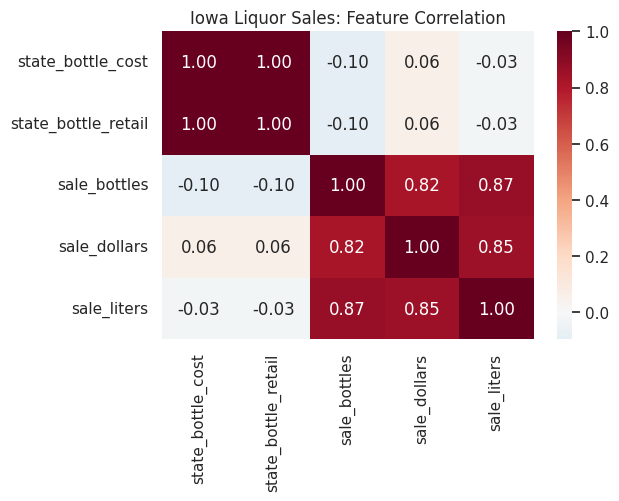

In [11]:
sns.set_theme(style="whitegrid")

cols_to_corr = ['state_bottle_cost', 'state_bottle_retail', 'sale_bottles', 'sale_dollars', 'sale_liters']
correlation_data = df[cols_to_corr].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_data, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Iowa Liquor Sales: Feature Correlation')
plt.show()

In [12]:
# Correlation for actual Sales
sales_corr = df[df['transaction_type'] == 'SALE'][cols_to_corr].corr()

# Correlation for Returns
returns_corr = df[df['transaction_type'] == 'RETURN'][cols_to_corr].corr()

# Difference in Dollars vs Liters
print(f"Sales Correlation (Liters/Dollars): {sales_corr.loc['sale_liters', 'sale_dollars']:.4f}")
print(f"Returns Correlation (Liters/Dollars): {returns_corr.loc['sale_liters', 'sale_dollars']:.4f}")

Sales Correlation (Liters/Dollars): 0.8525
Returns Correlation (Liters/Dollars): 0.7687


In [23]:
category_list = sorted(df['category_name'].dropna().unique().tolist())

for category in category_list:
    print(f"'{category}'")

'100% AGAVE TEQUILA'
'AGED DARK RUM'
'AMERICAN BRANDIES'
'AMERICAN CORDIALS & LIQUEURS'
'AMERICAN DISTILLED SPIRITS SPECIALTY'
'AMERICAN DRY GINS'
'AMERICAN FLAVORED VODKA'
'AMERICAN SCHNAPPS'
'AMERICAN SLOE GINS'
'AMERICAN VODKAS'
'BLENDED WHISKIES'
'BOTTLED IN BOND BOURBON'
'CANADIAN WHISKIES'
'COCKTAILS/RTD'
'COFFEE LIQUEURS'
'CORN WHISKIES'
'CREAM LIQUEURS'
'FLAVORED GIN'
'FLAVORED RUM'
'GOLD RUM'
'IMPORTED BRANDIES'
'IMPORTED CORDIALS & LIQUEURS'
'IMPORTED DISTILLED SPIRITS SPECIALTY'
'IMPORTED DRY GINS'
'IMPORTED FLAVORED VODKA'
'IMPORTED SCHNAPPS'
'IMPORTED VODKAS'
'IRISH WHISKIES'
'MEZCAL'
'MIXTO TEQUILA'
'NEUTRAL GRAIN SPIRITS'
'NEUTRAL GRAIN SPIRITS FLAVORED'
'SCOTCH WHISKIES'
'SINGLE BARREL BOURBON WHISKIES'
'SINGLE MALT SCOTCH'
'SPECIAL ORDER ITEMS'
'SPICED RUM'
'STRAIGHT BOURBON WHISKIES'
'STRAIGHT RYE WHISKIES'
'TEMPORARY & SPECIALTY PACKAGES'
'TENNESSEE WHISKIES'
'TRIPLE SEC'
'WHISKEY LIQUEUR'
'WHITE RUM'


In [25]:
vendor_list = sorted(df['vendor_name'].dropna().unique().tolist())

for vendor in vendor_list:
    print(f"'{vendor}'")

'10TH MOUNTAIN WHISKEY AND SPIRIT COMPANY'
'15 STARS, LLC'
'173 CRAFT DISTILLERY'
'21ST CENTURY SPIRITS LLC'
'3 BADGE CORPORATION'
'45TH PARALLEL SPIRITS'
'ABSINTHIA'S BOTTLED SPIRITS, LLC'
'AIKO IMPORTERS INC'
'ALLTECH BEVERAGE DIVISION LLC'
'AMERICAN HERITAGE DISTILLERS, LLC / CENTURY FARMS DISTILLERY'
'AMERICAN PREMIUM VODKA, LLC'
'AMERICAN SPIRITS EXCHANGE'
'ATOMIC BRANDS INC'
'ATOTO IMPORTS INCORPORATED'
'BACARDI USA INC'
'BAD BEAR ENTERPRISES LLC / LEGENDARY RYE'
'BALUARTE SPIRITS LLC'
'BEST CASE WINES LLC'
'BIG DERBY DISTILLING COMPANY'
'BLACK ROCK SPIRITS'
'BLUE MERANTI, LLC'
'BLUE MERANTI, LLC/HELMSMAN IMPORTS'
'BLUE OX SPIRITS, INC.'
'BRECKENRIDGE DISTILLERY / DOUBLE DIAMOND DISTILLERY LLC'
'BROWN FORMAN CORP.'
'BUZZARDS ROOST SPIRITS LLC'
'CADRE NOIR LLC / CNI BRANDS'
'CALEDONIA SPIRITS'
'CAMPARI AMERICA'
'CARIBBEAN SPIRITS INC'
'CARRIAGE HOUSE IMPORTS'
'CASA 1921 LLC'
'CASTLE BRANDS'
'CATS EYE DISTILLERY'
'CEDAR RIDGE VINEYARDS LL'
'CEO DISTILLING LLC'
'CH DISTILLERY / 773 

In [24]:
vodka_variations = df[df['category_name'].str.contains('VODKA', case=False, na=False)]['category_name'].unique()
print("\n--- All variations of 'Vodka' in the dataset ---")
print(vodka_variations)


--- All variations of 'Vodka' in the dataset ---
<ArrowStringArray>
[        'AMERICAN VODKAS', 'IMPORTED FLAVORED VODKA',
         'IMPORTED VODKAS', 'AMERICAN FLAVORED VODKA']
Length: 4, dtype: str
